# Sleep stages, awakenings, and heart rate

This notebook reconstructs Garmin Type 49 sleep-stage transitions. Garmin labels are estimates rather than clinical EEG measurements; the primary analysis preserves them unchanged.

In [1]:
from garmin_daylio_analysis.sleep import load_local_sleep_analysis
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

sleep = load_local_sleep_analysis()
nights, segments, signals, awakenings = sleep.nights, sleep.segments, sleep.signals, sleep.awakenings
recent_cutoff = (pd.Timestamp(nights.sleep_date.max()) - pd.DateOffset(months=3)).date()
recent_segments = segments.loc[segments.sleep_date >= recent_cutoff].copy()
raw_awakenings = awakenings.loc[(awakenings.scenario == "raw") & (awakenings.sleep_date >= recent_cutoff)].copy()
print(f"Reconstructed {len(recent_segments):,} stage segments across {recent_segments.sleep_date.nunique()} recent nights.")
print(f"Raw Garmin awakening events in this period: {len(raw_awakenings):,}.")

Reconstructed 1,023 stage segments across 52 recent nights.
Raw Garmin awakening events in this period: 183.


## What a raw Garmin Type 49 FIT file contains

FIT is Garmin's compact binary activity-file format. Here, **Type 49** is the file type recorded in the file header for a sleep file. The useful records inside it are timestamped `sleep_level` transitions: each one says that Garmin changed its current estimate to a stage such as light, deep, REM, or awake. A hypnogram is reconstructed by treating each transition's label as applying until the next transition. The small table below decodes the first few transitions from one Type 49 file without displaying its filename or any device identifiers.

In [2]:
from pathlib import Path
import zipfile
from garmin_daylio_analysis.sleep import _decode_fit, _read_file_id, _uploaded_archives

repo_root = next(parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / "config.local.toml").is_file())
example_transitions = None
for archive_path in _uploaded_archives(repo_root / "input" / "garmin_download"):
    with zipfile.ZipFile(archive_path) as archive:
        for member in archive.infolist():
            if member.is_dir() or not member.filename.lower().endswith(".fit"):
                continue
            data = archive.read(member)
            file_id = _read_file_id(data)
            if str(file_id.get("type")) == "49":
                example_transitions = pd.DataFrame(_decode_fit(data).get("sleep_level_mesgs", []))
                break
    if example_transitions is not None:
        break
display(example_transitions.loc[:, ["timestamp", "sleep_level"]].head(8))

,timestamp,sleep_level
0,2024-12-30 23:59:00+00:00,light
1,2024-12-31 00:52:00+00:00,deep
2,2024-12-31 01:02:00+00:00,light
3,2024-12-31 01:08:00+00:00,awake
4,2024-12-31 01:18:00+00:00,light
5,2024-12-31 01:56:00+00:00,deep
6,2024-12-31 02:04:00+00:00,light
7,2024-12-31 02:20:00+00:00,deep


## Stage timing for every recent night

Each row is one night. The horizontal position is hours since that night's first reconstructed stage, so the chart shows when stages occurred within each sleep window.

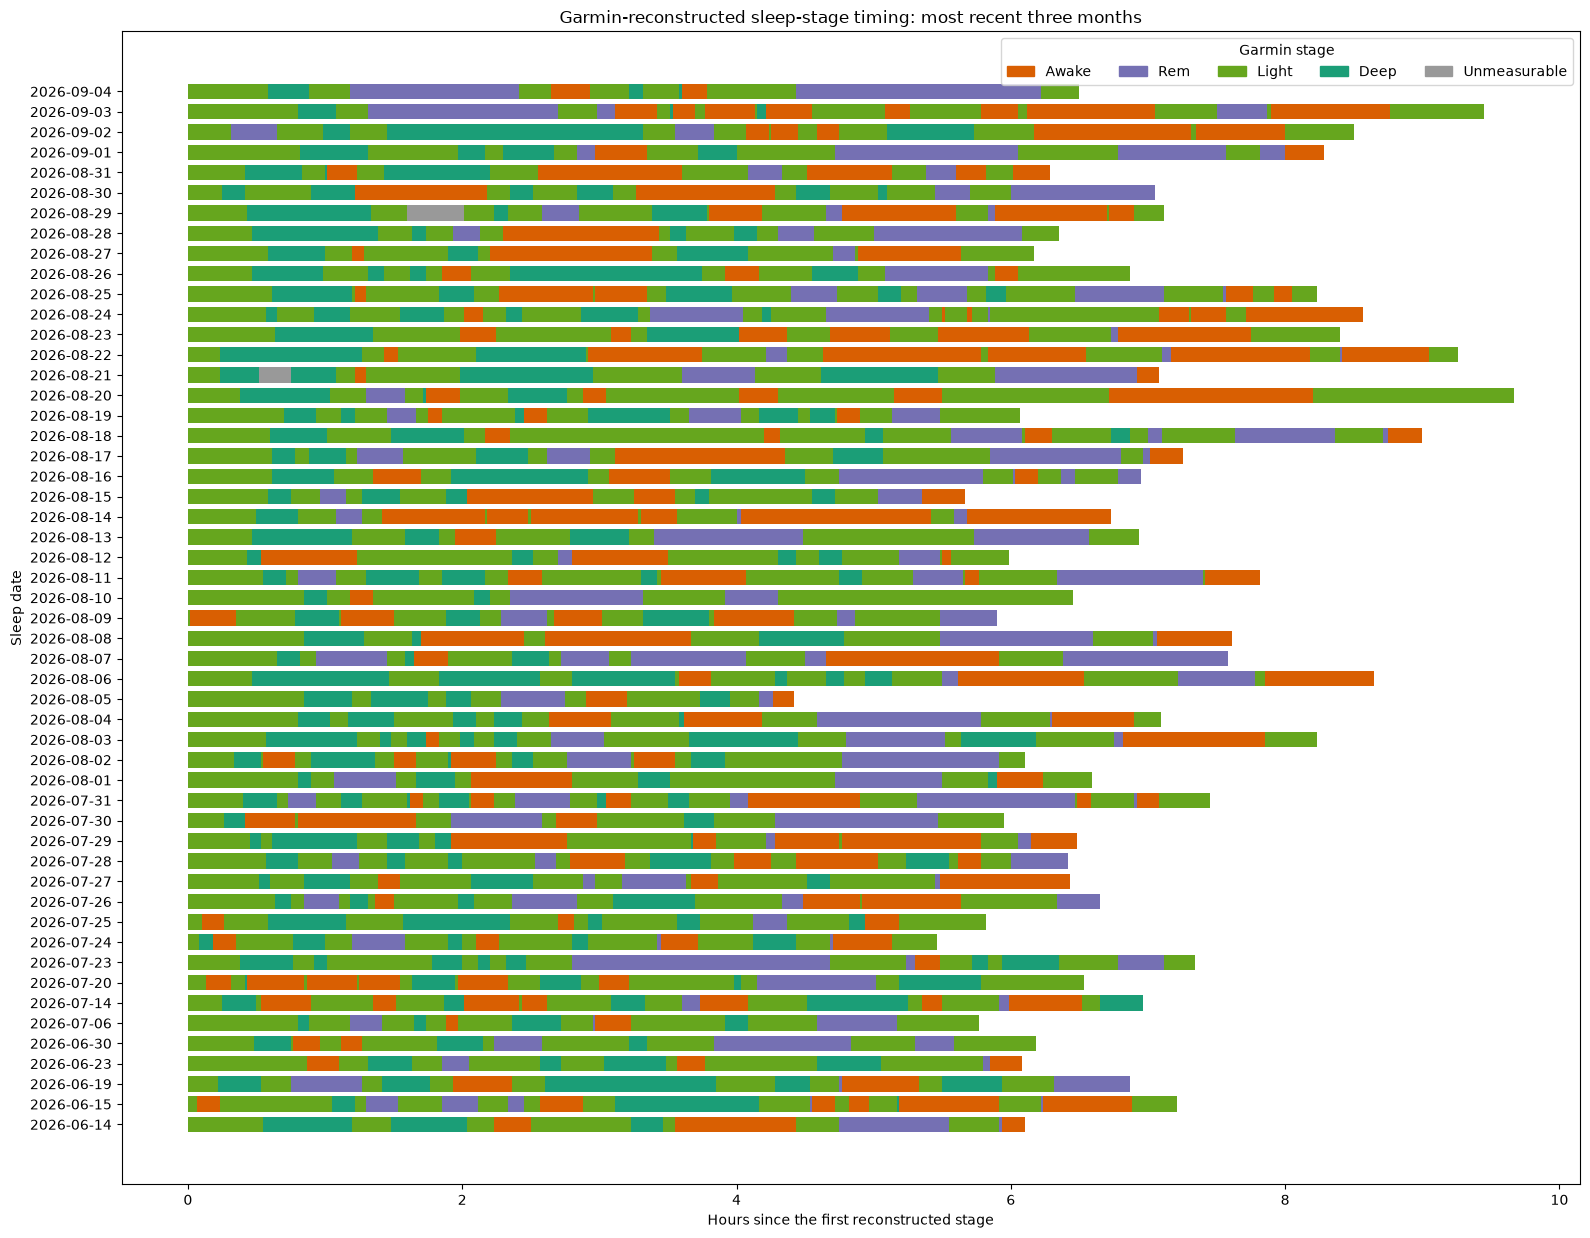

In [3]:
stage_colours = {"awake": "#d95f02", "rem": "#7570b3", "light": "#66a61e", "deep": "#1b9e77", "unmeasurable": "#999999"}
ordered_dates = sorted(recent_segments.sleep_date.unique())
fig, ax = plt.subplots(figsize=(16, max(9, len(ordered_dates) * 0.24)))
for row, sleep_date in enumerate(ordered_dates):
    night = recent_segments.loc[recent_segments.sleep_date == sleep_date].sort_values("start_utc")
    night_start = night.start_utc.iloc[0]
    for segment in night.itertuples():
        offset_hours = (segment.start_utc - night_start).total_seconds() / 3600
        ax.broken_barh([(offset_hours, segment.duration_minutes / 60)], (row - 0.38, 0.76), facecolors=stage_colours[segment.raw_stage])
ax.set_yticks(range(len(ordered_dates)), [str(value) for value in ordered_dates])
ax.set_xlabel("Hours since the first reconstructed stage")
ax.set_ylabel("Sleep date")
ax.set_title("Garmin-reconstructed sleep-stage timing: most recent three months")
ax.legend(handles=[Patch(color=colour, label=stage.title()) for stage, colour in stage_colours.items()], title="Garmin stage", ncols=5, loc="upper right")
plt.tight_layout()

## Representative hypnogram with heart rate

This selects the latest recent night with at least 100 overnight heart-rate readings and at least one raw Garmin awakening.

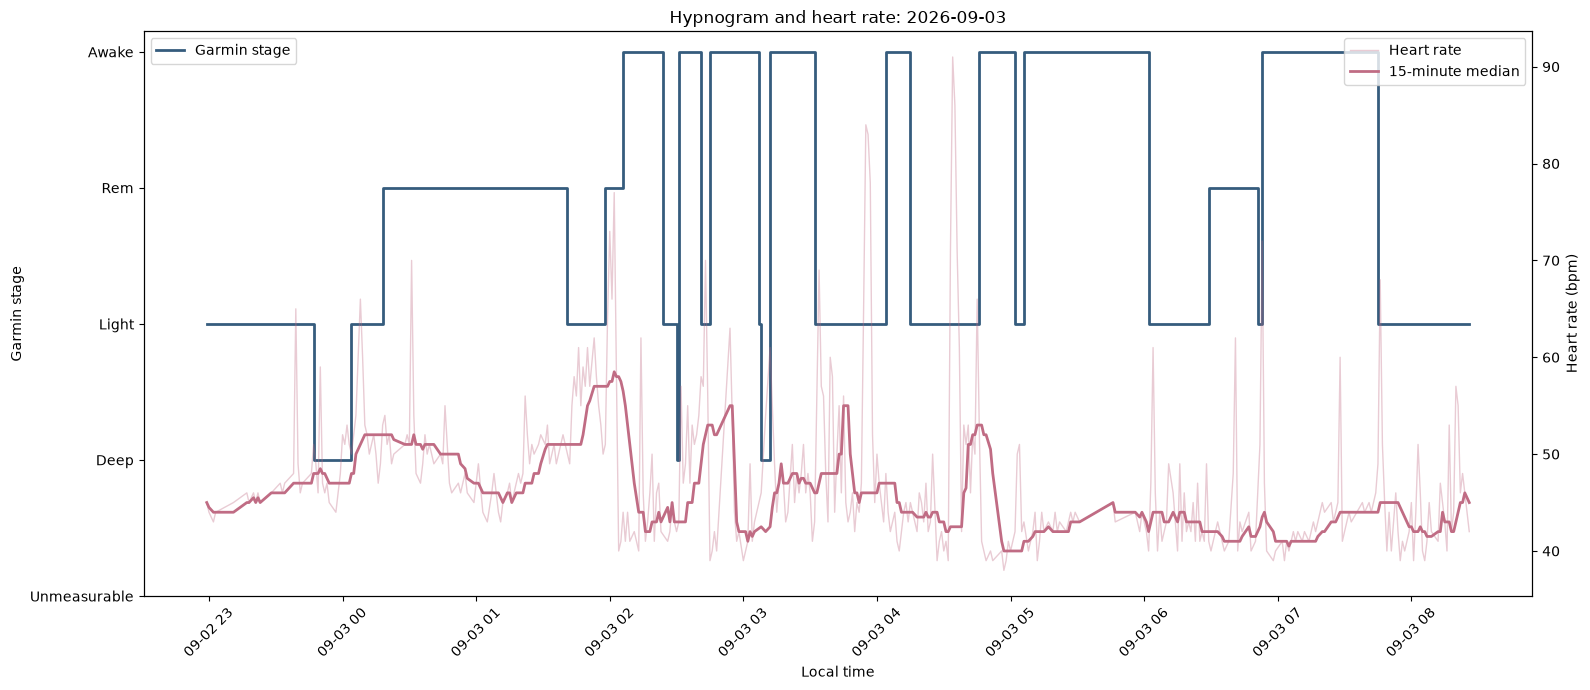

In [4]:
hr_counts = signals.loc[(signals.sleep_date >= recent_cutoff) & signals.heart_rate.notna()].groupby("sleep_date").size()
awakening_dates = set(raw_awakenings.sleep_date)
representative_date = max(date for date, count in hr_counts.items() if count >= 100 and date in awakening_dates)
representative_segments = recent_segments.loc[recent_segments.sleep_date == representative_date].sort_values("start_utc")
representative_hr = signals.loc[(signals.sleep_date == representative_date) & signals.heart_rate.notna()].sort_values("timestamp_local")
representative_hr_rolling = representative_hr.set_index("timestamp_local").heart_rate.rolling("15min", min_periods=1).median()
stage_levels = {"awake": 4, "rem": 3, "light": 2, "deep": 1, "unmeasurable": 0}
hypnogram_x = list(representative_segments.start_local) + [representative_segments.end_local.iloc[-1]]
hypnogram_y = [stage_levels[value] for value in representative_segments.raw_stage] + [stage_levels[representative_segments.raw_stage.iloc[-1]]]
fig, stage_ax = plt.subplots(figsize=(16, 7))
stage_ax.step(hypnogram_x, hypnogram_y, where="post", color="#355c7d", linewidth=2, label="Garmin stage")
stage_ax.set_yticks(list(stage_levels.values()), [name.title() for name in stage_levels])
stage_ax.set_ylabel("Garmin stage")
stage_ax.set_xlabel("Local time")
stage_ax.set_title(f"Hypnogram and heart rate: {representative_date}")
hr_ax = stage_ax.twinx()
hr_ax.plot(representative_hr.timestamp_local, representative_hr.heart_rate, color="#c06c84", alpha=0.35, linewidth=1, label="Heart rate")
hr_ax.plot(representative_hr_rolling.index, representative_hr_rolling, color="#c06c84", linewidth=2, label="15-minute median")
hr_ax.set_ylabel("Heart rate (bpm)")
stage_ax.tick_params(axis="x", rotation=45)
stage_ax.legend(loc="upper left")
hr_ax.legend(loc="upper right")
fig.tight_layout()

## Stage immediately before a raw Garmin awakening

This describes Garmin's stage-transition pattern; it does not establish why an awakening happened.

In [5]:
preceding_rows = []
for event in raw_awakenings.itertuples():
    night = recent_segments.loc[recent_segments.sleep_date == event.sleep_date].sort_values("start_utc")
    preceding = night.loc[night.end_utc <= event.start_utc]
    if not preceding.empty:
        prior = preceding.iloc[-1]
        preceding_rows.append({"sleep_date": event.sleep_date, "awakening_start_utc": event.start_utc, "prior_stage": prior.raw_stage, "awakening_minutes": event.duration_minutes})
awakening_context = pd.DataFrame(preceding_rows)
stage_before_awakenings = awakening_context.prior_stage.value_counts().rename_axis("prior_stage").to_frame("awakening_count")
stage_before_awakenings["percentage"] = stage_before_awakenings.awakening_count / stage_before_awakenings.awakening_count.sum() * 100
display(stage_before_awakenings)

,awakening_count,percentage
prior_stage,,
light,116,63.387978
rem,41,22.404372
deep,26,14.207650


## Heart rate in the 10 minutes before an awakening

For each raw Garmin awakening, this compares mean heart rate in the preceding 10 minutes with that same night's overall mean heart rate. Events need at least three pre-awakening readings. A positive difference means heart rate was above its typical level for that night before Garmin marked the interval awake. This can indicate an arousal-associated pattern, but cannot identify the cause, such as a dream or an external disturbance.

,above_night_mean_bpm,pre_awake_hr_bpm,night_mean_hr_bpm
events,179.000000,NaN,NaN
median_pre_awake_hr_bpm,NaN,48.800000,NaN
median_night_mean_hr_bpm,NaN,NaN,45.250000
median_above_night_mean_bpm,3.575521,NaN,NaN
mean_above_night_mean_bpm,4.069901,NaN,NaN
percentage_above_night_mean,74.301676,74.301676,74.301676


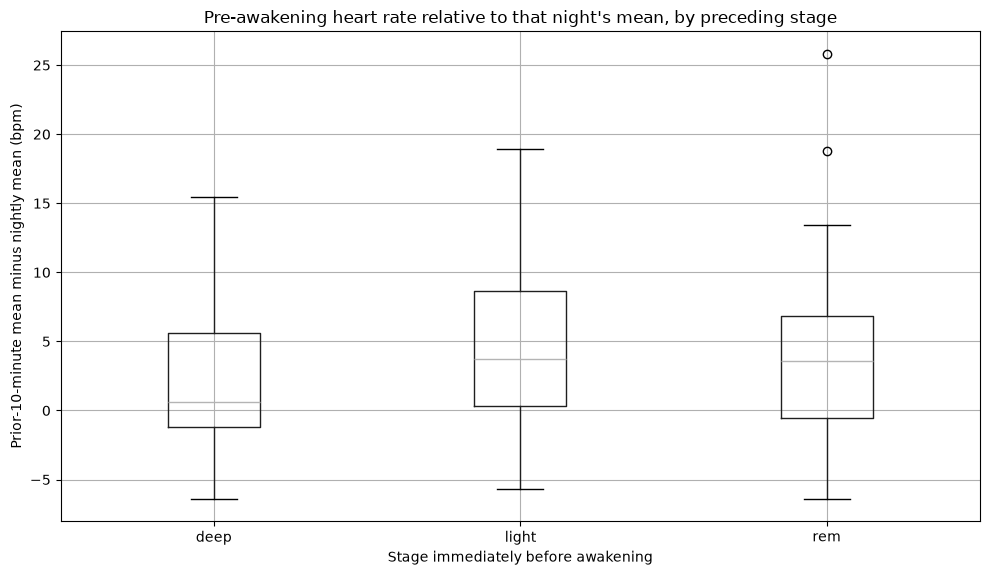

In [6]:
heart_rate_rows = []
for event in raw_awakenings.itertuples():
    event_signals = signals.loc[(signals.sleep_date == event.sleep_date) & signals.heart_rate.notna()]
    pre = event_signals.loc[(event_signals.timestamp_utc >= event.start_utc - pd.Timedelta(minutes=10)) & (event_signals.timestamp_utc < event.start_utc), "heart_rate"]
    prior_stage = awakening_context.loc[awakening_context.awakening_start_utc == event.start_utc, "prior_stage"]
    if len(pre) >= 3 and not prior_stage.empty:
        heart_rate_rows.append({"sleep_date": event.sleep_date, "prior_stage": prior_stage.iloc[0], "pre_awake_hr_bpm": pre.mean(), "night_mean_hr_bpm": event_signals.heart_rate.mean(), "above_night_mean_bpm": pre.mean() - event_signals.heart_rate.mean()})
heart_rate_events = pd.DataFrame(heart_rate_rows)
heart_rate_summary = heart_rate_events.agg(events=("above_night_mean_bpm", "count"), median_pre_awake_hr_bpm=("pre_awake_hr_bpm", "median"), median_night_mean_hr_bpm=("night_mean_hr_bpm", "median"), median_above_night_mean_bpm=("above_night_mean_bpm", "median"), mean_above_night_mean_bpm=("above_night_mean_bpm", "mean"))
heart_rate_summary.loc["percentage_above_night_mean"] = (heart_rate_events.above_night_mean_bpm > 0).mean() * 100
display(heart_rate_summary)

ax = heart_rate_events.boxplot(column="above_night_mean_bpm", by="prior_stage", figsize=(10, 6))
plt.suptitle("")
ax.set_title("Pre-awakening heart rate relative to that night's mean, by preceding stage")
ax.set_xlabel("Stage immediately before awakening")
ax.set_ylabel("Prior-10-minute mean minus nightly mean (bpm)")
plt.tight_layout()

## Heart rate and movement-derived fields by Garmin stage

Each signal timestamp is assigned to the reconstructed stage interval containing it. `steps`, `activity_type`, and `intensity` are the higher-level fields included in the monitoring FIT records. They are not raw accelerometer data, and this export does not expose a documented per-minute Garmin movement score. The summary therefore reports those fields directly rather than combining them into an arbitrary score.

,signal_samples,heart_rate_readings,mean_heart_rate_bpm,median_heart_rate_bpm,intensity_readings,mean_intensity,step_readings,step_positive_samples,intensity_positive_samples,step_positive_percentage,intensity_positive_percentage
raw_stage,,,,,,,,,,,
awake,4627,3340,44.78,43.0,780,1.11,13,13,359,0.28,7.76
light,9676,6763,45.75,44.0,1804,1.32,46,46,880,0.48,9.09
deep,3976,2953,45.74,44.0,741,1.22,16,16,359,0.40,9.03
rem,3178,2272,45.35,44.0,582,1.39,12,12,293,0.38,9.22
unmeasurable,39,24,41.62,41.5,7,1.14,0,0,3,0.00,7.69


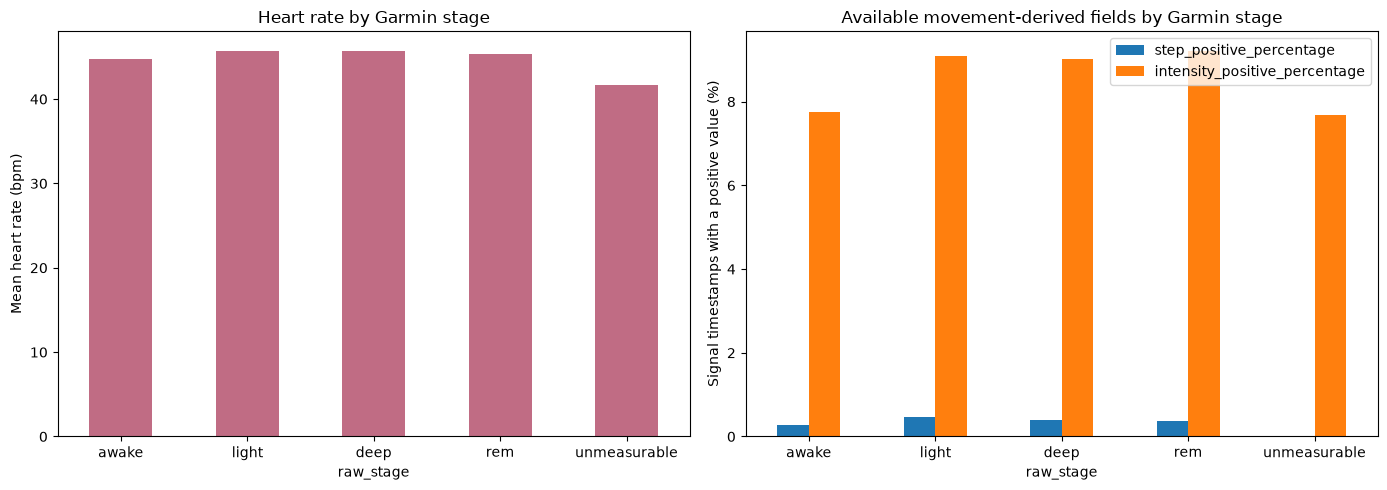

In [7]:
stage_signal_frames = []
for segment in recent_segments.itertuples():
    matching_signals = signals.loc[(signals.timestamp_utc >= segment.start_utc) & (signals.timestamp_utc < segment.end_utc)].copy()
    if not matching_signals.empty:
        matching_signals["raw_stage"] = segment.raw_stage
        stage_signal_frames.append(matching_signals)
stage_signals = pd.concat(stage_signal_frames, ignore_index=True)
stage_signals["steps_positive"] = stage_signals.steps.fillna(0).gt(0)
stage_signals["intensity_positive"] = stage_signals.intensity.fillna(0).gt(0)
stage_summary = stage_signals.groupby("raw_stage").agg(signal_samples=("timestamp_utc", "size"), heart_rate_readings=("heart_rate", "count"), mean_heart_rate_bpm=("heart_rate", "mean"), median_heart_rate_bpm=("heart_rate", "median"), intensity_readings=("intensity", "count"), mean_intensity=("intensity", "mean"), step_readings=("steps", "count"), step_positive_samples=("steps_positive", "sum"), intensity_positive_samples=("intensity_positive", "sum"))
stage_summary["step_positive_percentage"] = stage_signals.groupby("raw_stage").steps_positive.mean() * 100
stage_summary["intensity_positive_percentage"] = stage_signals.groupby("raw_stage").intensity_positive.mean() * 100
stage_summary = stage_summary.reindex(["awake", "light", "deep", "rem", "unmeasurable"]).dropna(how="all")
display(stage_summary.round(2))

fig, (heart_rate_ax, movement_ax) = plt.subplots(1, 2, figsize=(14, 5))
stage_summary.mean_heart_rate_bpm.plot(kind="bar", ax=heart_rate_ax, color="#c06c84")
heart_rate_ax.set_ylabel("Mean heart rate (bpm)")
heart_rate_ax.set_title("Heart rate by Garmin stage")
heart_rate_ax.tick_params(axis="x", rotation=0)
stage_summary[["step_positive_percentage", "intensity_positive_percentage"]].plot(kind="bar", ax=movement_ax)
movement_ax.set_ylabel("Signal timestamps with a positive value (%)")
movement_ax.set_title("Available movement-derived fields by Garmin stage")
movement_ax.tick_params(axis="x", rotation=0)
fig.tight_layout()

## What this can and cannot say about Garmin's staging

Garmin says its advanced sleep tracking considers heart rate, heart-rate variability (HRV), and body movement; compatible devices may also use respiratory signals. This notebook can show how the exported, higher-level heart-rate and movement-derived fields differ across Garmin's *already assigned* stages. It cannot reverse-engineer Garmin's proprietary model or prove which input caused any individual stage label.